In [19]:
#z score and outlier calcul;ation 
import pandas as pd 
import matplotlib.pyplot as plt
from scipy.stats import zscore,norm

In [6]:
df = pd.read_csv(r"C:\Users\PGCP-AI.STUDENTSDC\Downloads\diabetes.csv")
df['Glucose_z'] = zscore(df['Glucose'])


In [11]:
outliers = df[abs(df['Glucose_z']) > 3]
print('No. of outliers =', len(outliers))
print(outliers[['Glucose', 'Glucose_z']])

No. of outliers = 5
     Glucose  Glucose_z
75         0  -3.783654
182        0  -3.783654
342        0  -3.783654
349        0  -3.783654
502        0  -3.783654


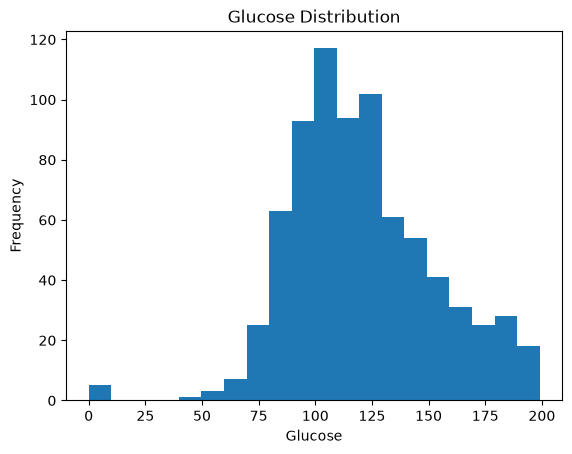

In [12]:
plt.hist(df['Glucose'], bins=20)
plt.xlabel('Glucose')
plt.ylabel('Frequency')
plt.title('Glucose Distribution')
plt.show()

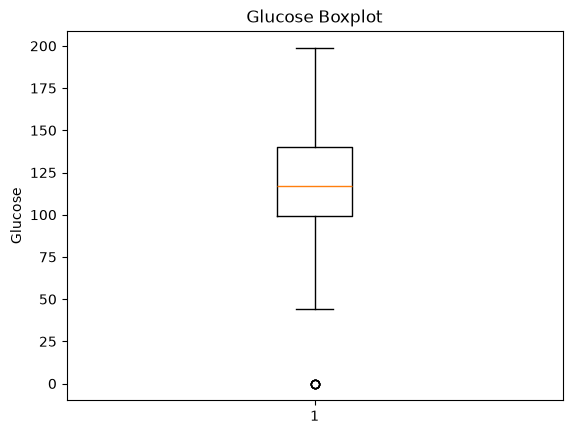

In [14]:
plt.boxplot(df['Glucose'])
plt.ylabel('Glucose')
plt.title('Glucose Boxplot')
plt.show()

In [15]:
# probablity calculation
x = 100
y = 140
mean = df['Glucose'].mean()
std = df['Glucose'].std()
print('\nMean Glucose =', mean)
print('std Glucose =', std)


Mean Glucose = 120.89453125
std Glucose = 31.97261819513622


In [17]:
# 1. people with glucose between x & y
between = df[(df['Glucose'] >= x) & (df['Glucose'] <= y)]
print('\nBetween', x,'and' ,y)
print('Count = ',len(between))
print('Percentage = ',len(between)/len(df) * 100)


Between 100 and 140
Count =  379
Percentage =  49.34895833333333


In [20]:
# normal distribution probability
p_between = norm.cdf(y,mean,std) - norm.cdf(x,mean,std)
print('Normal Probability =',p_between)

Normal Probability = 0.46821958211558595


In [21]:
# 2. People with glucose up to x
up_to_x = df[df['Glucose'] <= x]
print('\nUpto', x)
print('Count =',len(up_to_x))
print('Percentage =',len(up_to_x) / len(df) * 100)


Upto 100
Count = 214
Percentage = 27.864583333333332


In [22]:
# Normal Distribution CDF
p_up_to_x = norm.cdf(x,mean,std)
print('Normal Probability =',p_up_to_x)

Normal Probability = 0.256712708745466


In [23]:
# 3. people With Glucose above x
above_x = df[df['Glucose'] > x]
print('\nAbove', x)
print('Count =',len(above_x))
print('Percentage =',len(above_x) / len(df) * 100)


Above 100
Count = 554
Percentage = 72.13541666666666


In [24]:
# 1 - cdf
p_above_x = 1 - norm.cdf(x,mean,std)
print('Normal Probability =',p_above_x)

Normal Probability = 0.7432872912545341


In [ ]:
""" 
Excercise 

1. Read sachin_tendulkar.csv and calculate the mean, meadian, minimun , maximum and standard deviation of runs.
plot a histogram of runs.
2. Calculate the z_score of runs for every innings. Identify inning where |z|>3. Print the number of outliers and display 
their runs and z_score
3. plot a histogram of runs using 20 bins and a boxplot of runs. Identify unusually high-scoring innings using the boxplot.
4. calculate the zscore for balls_faced. identify innings where |z| > 3. Display Runs , BALLS_FACED and the zscore for 
these innings
5. calculate a new column run_per_ball = Runs / balls_faced. Calculate its means and std. Plot its histogram and boxplot.
Identify outlier using zscore
6. for x = 50 and y=100 , find thye number and percentage of innings where runs were between x and y. using a normal 
distribution, 
cal prob using cdf(y) - cdf(x)
7. for x = 50  , find the number and percentage of innings where runs were upto x. using a normal distribution, 
cal prob using cdf(x)
8. for x = 100, find thye number and percentage of innings where runs were above x . using a normal distribution, 
cal prob using 1 - cdf(x)
9. group the data by versus and cal the mean runs against each team. Display the teams in descending order of 
average runs amd plot a bar chart 
10. identify innings where runs>=100, runs>=50 and runs==0. calculate the number and percentage of innings in each category 
and plot a bar chart comparing the three categories.

"""

In [36]:
df = pd.read_csv('Sachin_tendulkar.csv')
df.head(10)

,Match_No,Innings,match_date,Versus,mode_of_dismissal,Runs,Balls_faced
0,1,1,1989-12-18 00:00:00,Pakistan,c Wasim Akram b Waqar Younis,0,2
1,2,2,1990-03-01 00:00:00,New Zealand,c & b S A Thomson,0,2
2,3,3,1990-03-06 00:00:00,New Zealand,c †I D S Smith b S A Thomson,36,39
3,4,4,1990-04-25 00:00:00,Sri Lanka,run out,10,12
4,5,5,1990-04-27 00:00:00,Pakistan,c Saeed Anwar b Imran Khan,20,25
5,6,6,1990-07-18 00:00:00,England,b D E Malcolm,19,35
6,7,7,1990-07-20 00:00:00,England,b A R C Fraser,31,26
7,8,8,1990-12-01 00:00:00,Sri Lanka,b R J Ratnayake,36,22
8,9,9,1990-12-05 00:00:00,Sri Lanka,b G F Labrooy,53,41
9,10,10,1990-12-08 00:00:00,Sri Lanka,c & b S D Anurasiri,30,29


In [35]:
print('Runs Mean :-',df['Runs'].mean())
print('Runs Median :-',df['Runs'].median())
print('Runs Minimum :-',df['Runs'].min())
print('Runs Maximum :-',df['Runs'].max())
print('Runs Standard Deviation :-',df['Runs'].std())

Runs Mean :- 40.76548672566372
Runs Median :- 28.5
Runs Minimum :- 0
Runs Maximum :- 200
Runs Standard Deviation :- 40.0394800064396


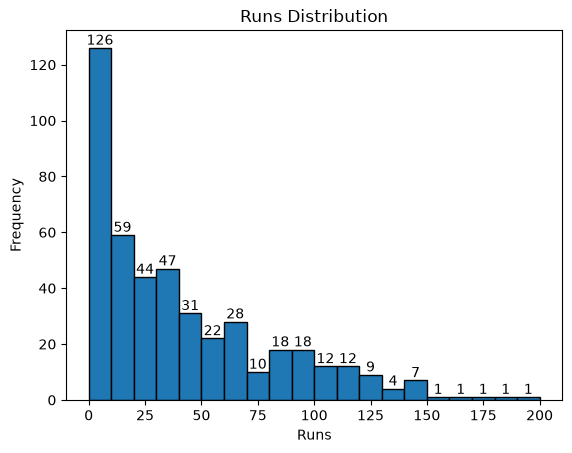

In [48]:
counts, bins, patches = plt.hist(df['Runs'],bins=20,edgecolor='black')
plt.bar_label(patches)
plt.title('Runs Distribution')
plt.xlabel('Runs')
plt.ylabel('Frequency')
plt.show()